# APRENDIZAJE AUTOMÁTICO
-------------------------

## Proyecto: Instancia de parcial  
## Profesor: Caballero Nicolás  
## Alumno: Calisaya Débora  
--------------


### **Título:** Modelado predictivo de la demanda eléctrica y simulación de escenarios críticos en el sistema energético aislado de Tierra del Fuego.
--------------

## Informe sobre el origen del dataset, de dónde provienen los datos (fuente, fecha de adquisición y preprocesamiento realizado)."


* **Fuente de los datos:** Los datos provienen del **Instituto Provincial de Análisis Estadístico y Censos (IPIEC)** de la Provincia de Tierra del Fuego, Antártida e Islas del Atlántico Sur. Se extrajeron de las series estadísticas de *Estadísticas Económicas - Energía Eléctrica*.
* **Portal Oficial:** [https://ipiec.tierradelfuego.gob.ar/estadisticas-economicas-2/](https://ipiec.tierradelfuego.gob.ar/estadisticas-economicas-2/)
* **Fecha de Adquisición:** desde 2010 hasta Junio de 2026.
* **Proceso de Recopilación y Desafío Técnico:** Los datos se encuentran en un único archivo Excel (`15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx`). La estructura de origen presenta la columna **"Período"** dividida jerárquicamente: el año se declara una sola vez al inicio de cada ciclo anual y los meses se listan consecutivamente en las filas inferiores de la misma columna. 

Para consolidar esto en Machine Learning, implementaremos una función ETL en Python que detecte los años, aplique una técnica de relleno hacia abajo (`ffill`), normalice las cadenas de texto de los meses a valores numéricos y unifique las pestañas de las localidades en una única matriz cronológica limpia.


### ● Importación de Librerías

In [1]:
# Importación de librerías esenciales para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización y Análisis Exploratorio de Datos (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración del entorno
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("Librerías base cargadas exitosamente.")

Librerías base cargadas exitosamente.


## 1. Carga y preprocesamiento del Dataset de población

In [2]:
from pathlib import Path

# 1. Cargamos el archivo (probamos con skiprows=4 por si el encabezado real está un renglón más abajo)
ruta_poblacion = globals().get(
    "path_poblacion",
    "data/01_02_01-Poblacion-estimada-al-1-de-julio-segun-ano-calendario-por-sexo.-TDF.-Anos-2010-2040-.xlsx"
)

ruta = Path(ruta_poblacion)

candidatas = [
    ruta,
    Path.cwd() / ruta,
    Path.cwd().parent / ruta,
    Path.cwd() / "data" / ruta.name,
    Path.cwd().parent / "data" / ruta.name,
]

for p in candidatas:
    if p.exists():
        ruta = p
        break
else:
    # Búsqueda robusta del archivo en ubicaciones comunes y subdirectorios del proyecto
    candidatos_extra = [
        ruta,
        Path.cwd() / ruta,
        Path.cwd().parent / ruta,
        Path.cwd() / "data" / ruta.name,
        Path.cwd().parent / "data" / ruta.name,
        Path.cwd() / "notebooks" / "data" / ruta.name,
        Path.cwd().parent / "notebooks" / "data" / ruta.name,
    ]

    for p in candidatos_extra:
        if p.exists():
            ruta = p
            break
    else:
        for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
            for archivo in base.rglob(ruta.name):
                if archivo.is_file():
                    ruta = archivo
                    break
            if ruta.exists():
                break

    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta_poblacion}")

path_poblacion = str(ruta)
df_poblacion_raw = pd.read_excel(path_poblacion, engine="openpyxl", skiprows=4)

# 2. Imprimimos los nombres reales de las columnas para estar 100% seguros de cómo las leyó Python
print("Columnas detectadas:", df_poblacion_raw.columns.tolist())

# 3. Filtramos y limpiamos (si las columnas se llaman igual, va a pasar de largo perfecto)
# El Excel trae los datos sin encabezados estándar.
# Tomamos por posición: 1ra columna = Año, 2da columna = Población total.
df_poblacion = df_poblacion_raw.iloc[:, :2].copy()

# Renombramos de forma robusta
df_poblacion.columns = ['Año', 'Poblacion_Estimada']

# Limpiamos filas sin datos reales
df_poblacion = df_poblacion.dropna(subset=['Año', 'Poblacion_Estimada']).copy()

# Nos quedamos solo con filas que tengan un año válido
df_poblacion = df_poblacion[
    df_poblacion['Año'].astype(str).str.match(r'^\d{4}$', na=False)
].copy()

# Convertimos a numéricos
df_poblacion['Año'] = pd.to_numeric(df_poblacion['Año'], errors='coerce').astype(int)
df_poblacion['Poblacion_Estimada'] = pd.to_numeric(df_poblacion['Poblacion_Estimada'], errors='coerce')

df_poblacion = df_poblacion.dropna().reset_index(drop=True)
df_poblacion['Año'] = df_poblacion['Año'].astype(int)
df_poblacion = df_poblacion.rename(columns={'Ambos sexos': 'Poblacion_Estimada'})

df_poblacion.head()

Columnas detectadas: [2010, 131661, 67235, 64426]


,Año,Poblacion_Estimada
0,2011,135742.0
1,2012,139852.0
2,2013,143987.0
3,2014,148143.0
4,2015,152317.0


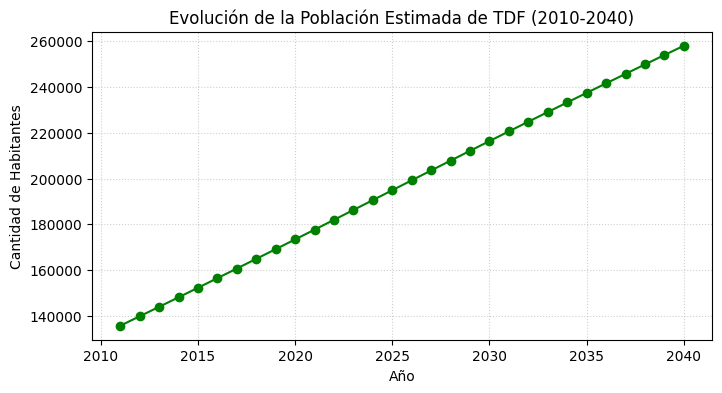

In [3]:
# 2. Evolución de la Población Estimada
plt.figure(figsize=(8, 4))
plt.plot(df_poblacion['Año'], df_poblacion['Poblacion_Estimada'], marker='o', color='green')
plt.title('Evolución de la Población Estimada de TDF (2010-2040)')
plt.xlabel('Año')
plt.ylabel('Cantidad de Habitantes')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [4]:
#informacion de la poblacion
print("Información de la población estimada:")
print(df_poblacion.info())
print(type(df_poblacion))

Información de la población estimada:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Año                 30 non-null     int64  
 1   Poblacion_Estimada  30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None
<class 'pandas.DataFrame'>


In [5]:
#correccion de tipo de datos de la columna poblacion estima de float a int64
df_poblacion['Poblacion_Estimada'] = df_poblacion['Poblacion_Estimada'].astype(int)
print("Tipo de datos de la columna 'Poblacion_Estimada' después de la conversión:", df_poblacion['Poblacion_Estimada'].dtype)

Tipo de datos de la columna 'Poblacion_Estimada' después de la conversión: int64


In [6]:
print("Primeras filas del dataset de población estimada:")
print(df_poblacion.head())

Primeras filas del dataset de población estimada:
    Año  Poblacion_Estimada
0  2011              135742
1  2012              139852
2  2013              143987
3  2014              148143
4  2015              152317


## 1. Carga del Dataset de energia

In [1]:
def procesar_hoja(nombre_hoja, nombre_columna_total):
    # usecols=[0, 1, 2] para tomar SOLO Período (Año), la columna sin nombre (Mes) y el Total (kWh)
    # Resolver la ruta del archivo Excel de forma robusta
    ruta_archivo = globals().get(
        "archivo_excel",
        globals().get("ruta_energia_input", globals().get("ruta_energia", "data/raw/15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx"))
    )

    ruta_excel = Path(ruta_archivo)

    if not ruta_excel.exists():
        candidatos = [
            Path.cwd() / ruta_excel,
            Path.cwd().parent / ruta_excel,
            Path.cwd().parent.parent / ruta_excel,
            Path.cwd() / "data" / "raw" / ruta_excel.name,
            Path.cwd().parent / "data" / "raw" / ruta_excel.name,
            Path.cwd() / "notebooks" / "data" / "raw" / ruta_excel.name,
            Path.cwd().parent / "notebooks" / "data" / "raw" / ruta_excel.name,
        ]
        ruta_excel = next((p for p in candidatos if p.exists()), None)

    if ruta_excel is None:
        raise FileNotFoundError(f"No se encontró el archivo Excel: {ruta_archivo}")

    df_hoja = pd.read_excel(str(ruta_excel), sheet_name=nombre_hoja, skiprows=3, usecols=[0, 1, 2], engine='openpyxl')
    
    # renombramos de forma fija y directa las 3 columnas para evitar el IndexError
    df_hoja.columns = ['Anio_Raw', 'Mes_Raw', nombre_columna_total]
    
    # limpiamos espacios invisibles en los textos
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].astype(str).str.strip()
    df_hoja['Mes_Raw'] = df_hoja['Mes_Raw'].astype(str).str.strip()
    
    # reemplazamos celdas vacías por NaN para poder propagar el año hacia abajo
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].replace(['nan', 'None', ''], np.nan)
    
    # filtramos filas que no contengan meses válidos o que sean basura
    df_hoja = df_hoja[df_hoja['Mes_Raw'].notna() & (df_hoja['Mes_Raw'] != 'nan')].reset_index(drop=True)
    
    # aplicamos Forward Fill (.ffill()) para que el Año se repita en sus 12 meses inferiores
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].ffill()
    
    # Diccionario para mapear los meses de texto a números
    meses_dict = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12,
        'noviembre ': 11, 'junio ': 6
    }
    
    fechas_limpias = []
    for idx, row in df_hoja.iterrows():
        try:
            # Quitamos los decimales del año (ej: de '2010.0' a 2010)
            anio_val = int(float(row['Anio_Raw']))
            mes_str = row['Mes_Raw'].lower()
            mes_val = meses_dict.get(mes_str, None)
            
            if mes_val is not None:
                fechas_limpias.append(pd.to_datetime(f"{anio_val}-{mes_val:02d}-01"))
            else:
                fechas_limpias.append(pd.NaT)
        except:
            fechas_limpias.append(pd.NaT)
            
    df_hoja['Fecha'] = fechas_limpias
    
    # eliminamos registros que no pudieron convertirse en fechas reales (totales anuales o notas)
    df_hoja = df_hoja.dropna(subset=['Fecha']).reset_index(drop=True)
    
    return df_hoja[['Fecha', nombre_columna_total]]

In [ ]:
#procesamos solo la hoja de Total TDF
from pathlib import Path

# Ejecutamos la carga leyendo toal del Excel del IPIEC
# Resolver correctamente la ruta del archivo Excel
archivo_excel = globals().get(
    "archivo_excel",
    globals().get(
        "path_energia",
        globals().get(
            "ruta_energia_input",
            globals().get("ruta_energia", "data/raw/15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx")
        ),
    ),
)
archivo_excel_path = Path(archivo_excel)

if not archivo_excel_path.exists():
    candidatos = [
        Path.cwd() / archivo_excel_path,
        Path.cwd().parent / archivo_excel_path,
        Path.cwd().parent.parent / archivo_excel_path,
    ]
    archivo_excel_path = next((p for p in candidatos if p.exists()), None)

if archivo_excel_path is None:
    raise FileNotFoundError(f"No se encontró el archivo Excel: {archivo_excel}")

archivo_excel = str(archivo_excel_path)

df_total_prov = procesar_hoja('Total TDF', 'Consumo_Total_Provincial')

print("Datos del IPIEC cargados y procesados exitosamente.")

NameError: name 'pd' is not defined

In [29]:
print("Primeras filas del dataset de consumo total provincial:")
print(df_total_prov.head())

c:\Users\debor\OneDrive\Desktop\TECNICATURA DE CS DE DATOS E IA\APRENDIZAJE-AUTOMATICO_InstanciaParcial_2026\data\raw\15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx
Primeras filas del dataset de consumo total provincial:
       Fecha Consumo_Total_Provincial
0 2010-01-01                 28389813
1 2010-02-01                 29604832
2 2010-03-01                 31100802
3 2010-04-01                 34441839
4 2010-05-01                 32849499


In [31]:
#unificacion de los datasets de consumo total provincial y población estimada
df_unificado = pd.merge(df_total_prov, df_poblacion, left_on=df_total_prov['Fecha'].dt.year, right_on=df_poblacion['Año'], how='inner')
print("Primeras filas del dataset unificado de consumo total provincial y población estimada:")
print(df_unificado.head())
#Contar la cantidad de filas y columnas del merge actual
filas, columnas = df_unificado.shape
print(f"Cantidad total de filas en el merge: {filas}")
print(f"Cantidad de columnas: {columnas}")

#Mostrar un resumen rápido de la estructura para ver si están los datos completos
print("\nResumen del DataFrame actual:")
df_unificado.info()



Primeras filas del dataset unificado de consumo total provincial y población estimada:
   key_0      Fecha Consumo_Total_Provincial   Año  Poblacion_Estimada
0   2011 2011-01-01                 28309904  2011              135742
1   2011 2011-02-01                 30370646  2011              135742
2   2011 2011-03-01                 32572518  2011              135742
3   2011 2011-04-01                 34153107  2011              135742
4   2011 2011-05-01                 35645290  2011              135742
Cantidad total de filas en el merge: 184
Cantidad de columnas: 5

Resumen del DataFrame actual:
<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   key_0                     184 non-null    int32         
 1   Fecha                     184 non-null    datetime64[us]
 2   Consumo_Total_Provincial  184 non-null    obj

In [33]:
#correccion de tipo de datos de la columna Consumo_Total_Provincial de object a float
df_unificado['Consumo_Total_Provincial'] = pd.to_numeric(df_unificado['Consumo_Total_Provincial'], errors='coerce')

# 2. Por si acaso quedó alguna fila con NaN tras la conversión, la eliminamos
df_unificado = df_unificado.dropna(subset=['Consumo_Total_Provincial']).copy()

# 3. Verificamos cuántas filas quedaron y si el tipo de dato cambió con éxito
print(f"Cantidad total de filas después de la corrección: {len(df_unificado)}")
print("\nTipos de datos actualizados de las columnas:")
print(df_unificado.dtypes)


Cantidad total de filas después de la corrección: 184

Tipos de datos actualizados de las columnas:
key_0                                int32
Fecha                       datetime64[us]
Consumo_Total_Provincial           float64
Año                                  int64
Poblacion_Estimada                   int64
dtype: object


In [34]:
# 1. Borramos las columnas 'key_0' y 'Año' ya que tenemos la columna 'Fecha' completa
df_unificado = df_unificado.drop(columns=['key_0', 'Año']).copy()

# 2. Verificamos cómo quedaron las columnas del dataset limpio
print("Columnas actuales después de la limpieza:")
print(df_unificado.columns.tolist())

# 3. Mostramos las primeras filas para asegurarnos de que todo se vea prolijo
df_unificado.head()

Columnas actuales después de la limpieza:
['Fecha', 'Consumo_Total_Provincial', 'Poblacion_Estimada']


,Fecha,Consumo_Total_Provincial,Poblacion_Estimada
0,2011-01-01,28309904.0,135742
1,2011-02-01,30370646.0,135742
2,2011-03-01,32572518.0,135742
3,2011-04-01,34153107.0,135742
4,2011-05-01,35645290.0,135742


In [35]:
# 1. Creamos los lags (valores pasados) sobre el consumo provincial numérico
df_unificado['Total_Mes_Anterior (t-1)'] = df_unificado['Consumo_Total_Provincial'].shift(1)
df_unificado['Total_Hace_2Meses (t-2)'] = df_unificado['Consumo_Total_Provincial'].shift(2)
df_unificado['Total_Anio_Anterior (t-12)'] = df_unificado['Consumo_Total_Provincial'].shift(12)

# 2. Variable estacional (Extraemos el mes del calendario como número del 1 al 12)
df_unificado['Mes_Calendario'] = df_unificado['Fecha'].dt.month

# 3. Guardamos en el DataFrame final eliminando los NaN que provocan los .shift()
# El .shift(12) te deja 12 filas vacías al inicio; con .dropna() las removemos para que Scikit-Learn no falle
df_dataset_final_p2 = df_unificado.dropna().reset_index(drop=True)

# 4. Verificamos la forma de la matriz final y las columnas resultantes
print(f"¡Dataset final consolidado! Dimensiones: {df_dataset_final_p2.shape}")
print("\nPrimeras filas del set de entrenamiento:")
df_dataset_final_p2.head()

¡Dataset final consolidado! Dimensiones: (172, 7)

Primeras filas del set de entrenamiento:


,Fecha,Consumo_Total_Provincial,Poblacion_Estimada,Total_Mes_Anterior (t-1),Total_Hace_2Meses (t-2),Total_Anio_Anterior (t-12),Mes_Calendario
0,2012-01-01,30091986.0,139852,32654705.0,33566246.0,28309904.0,1
1,2012-02-01,31786718.0,139852,30091986.0,32654705.0,30370646.0,2
2,2012-03-01,33522268.0,139852,31786718.0,30091986.0,32572518.0,3
3,2012-04-01,35271002.0,139852,33522268.0,31786718.0,34153107.0,4
4,2012-05-01,37707222.0,139852,35271002.0,33522268.0,35645290.0,5


# GRAFICOS EDA


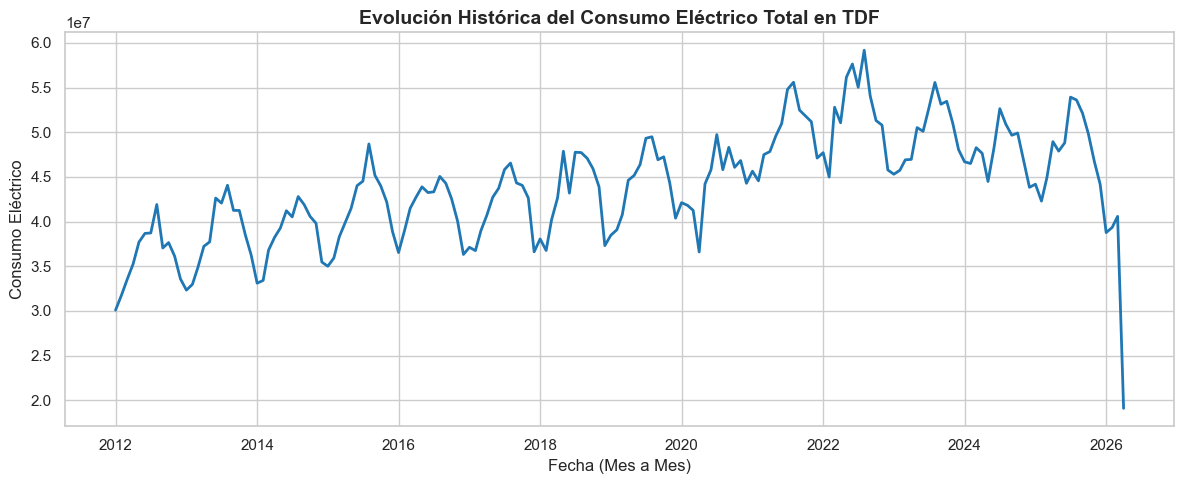

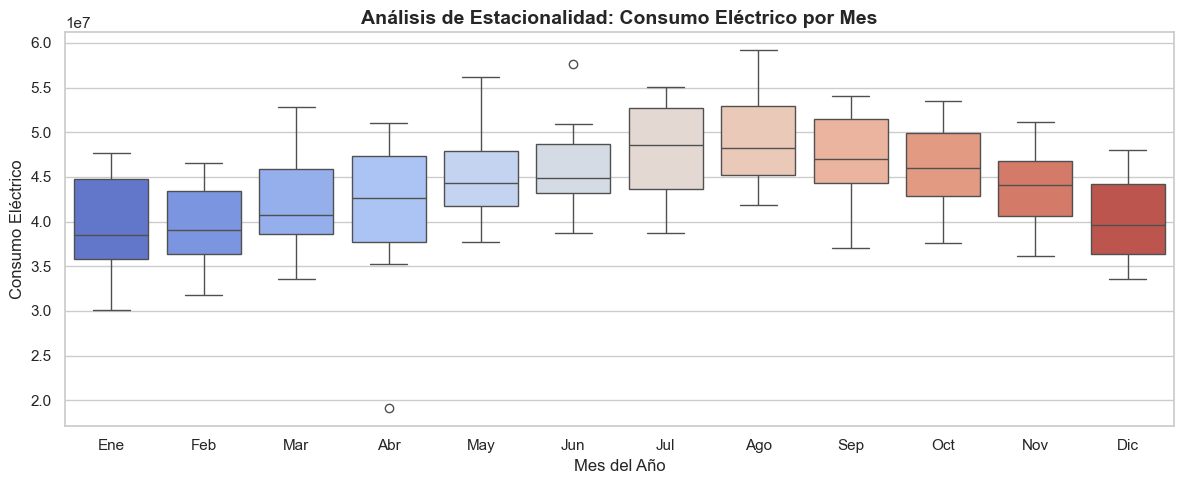

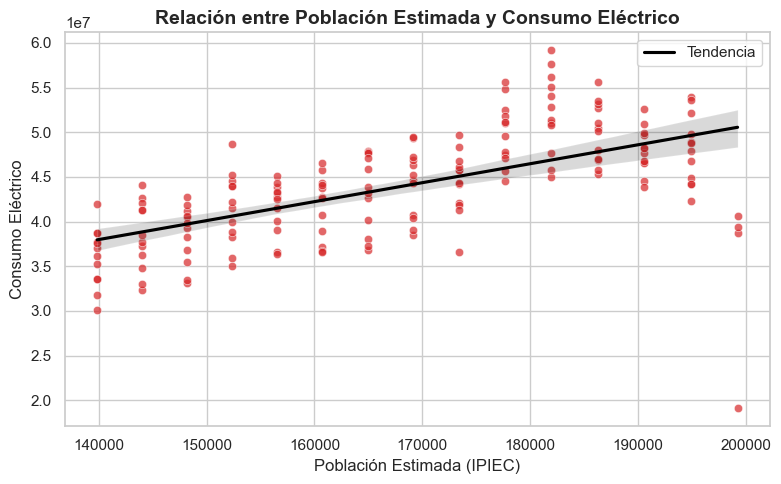

Coeficiente de correlación de Pearson entre Consumo y Población: 0.61


In [36]:
# Configuramos el estilo de los gráficos para que queden profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ==========================================
# GRÁFICO 1: Evolución Histórica del Consumo
# ==========================================
plt.figure()
sns.lineplot(data=df_dataset_final_p2, x='Fecha', y='Consumo_Total_Provincial', color='tab:blue', linewidth=2)
plt.title('Evolución Histórica del Consumo Eléctrico Total en TDF', fontsize=14, fontweight='bold')
plt.xlabel('Fecha (Mes a Mes)', fontsize=12)
plt.ylabel('Consumo Eléctrico', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO 2: Estacionalidad Mensual (Boxplot)
# ==========================================
plt.figure()
# Mapeamos los números de mes a nombres cortos para que el gráfico sea más legible
meses_nombres = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
df_plot_estacional = df_dataset_final_p2.copy()
df_plot_estacional['Mes_Nombre'] = df_plot_estacional['Mes_Calendario'].map(meses_nombres)

sns.boxplot(data=df_plot_estacional, x='Mes_Nombre', y='Consumo_Total_Provincial', palette='coolwarm', order=meses_nombres.values())
plt.title('Análisis de Estacionalidad: Consumo Eléctrico por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Consumo Eléctrico', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO 3: Correlación Consumo vs Población
# ==========================================
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_dataset_final_p2, x='Poblacion_Estimada', y='Consumo_Total_Provincial', color='tab:red', alpha=0.7)
sns.regplot(data=df_dataset_final_p2, x='Poblacion_Estimada', y='Consumo_Total_Provincial', scatter=False, color='black', label='Tendencia')
plt.title('Relación entre Población Estimada y Consumo Eléctrico', fontsize=14, fontweight='bold')
plt.xlabel('Población Estimada (IPIEC)', fontsize=12)
plt.ylabel('Consumo Eléctrico', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Extra: Mostramos la correlación numérica en texto para complementar
correlacion = df_dataset_final_p2['Consumo_Total_Provincial'].corr(df_dataset_final_p2['Poblacion_Estimada'])
print(f"Coeficiente de correlación de Pearson entre Consumo y Población: {correlacion:.2f}")

Del Gráfico 1: Vas a ver una clara tendencia hacia arriba (crecimiento vegetativo de la demanda) combinada con picos y valles repetitivos.

Del Gráfico 2: Vas a notar que los diagramas de caja de los meses de junio, julio y agosto (invierno) están desplazados hacia arriba, confirmando que el factor climático invernal es clave para el modelo.

Del Gráfico 3: Como la correlación da 0.61, la justificación "Incluimos la variable de población porque tiene una fuerte correlación lineal positiva con el consumo"

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Seleccionamos nuestras Variables Predictoras (X) y la Variable Objetivo (y)
columnas_X = [
    'Poblacion_Estimada', 
    'Total_Mes_Anterior (t-1)', 
    'Total_Hace_2Meses (t-2)', 
    'Total_Anio_Anterior (t-12)', 
    'Mes_Calendario'
]

X = df_dataset_final_p2[columnas_X]
y = df_dataset_final_p2['Consumo_Total_Provincial']

# 2. Separación Cronológica: 80% para entrenar y 20% para validar (Test)
# ¡Crucial usar shuffle=False para no romper la línea de tiempo!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 3. Inicializamos el modelo de Regresión Lineal y lo ENTRENAMOS
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# 4. Hacemos las predicciones con los datos que el modelo NO conoce (X_test)
y_pred = modelo_lr.predict(X_test)

# 5. Calculamos las métricas fundamentales para tu parcial
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 6. Imprimimos los resultados en pantalla
print("====== ¡MODELO ENTRENADO CON ÉXITO! ======")
print(f"Métricas de evaluación en el set de Testeo:")
print(f"• Coeficiente de Determinación (R² Score): {r2:.4f}")
print(f"• Error Absoluto Medio (MAE): {mae:,.2f}")
print(f"• Raíz del Error Cuadrático Medio (RMSE): {rmse:,.2f}")
print("==========================================")

====== ¡MODELO ENTRENADO CON ÉXITO! ======
Métricas de evaluación en el set de Testeo:
• Coeficiente de Determinación (R² Score): 0.4384
• Error Absoluto Medio (MAE): 2,403,483.67
• Raíz del Error Cuadrático Medio (RMSE): 4,763,019.55


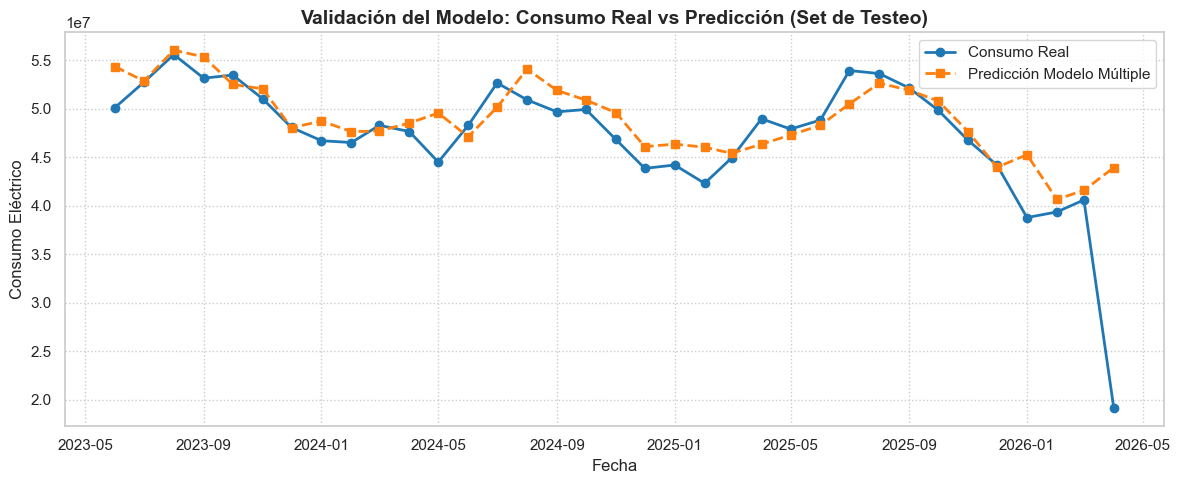

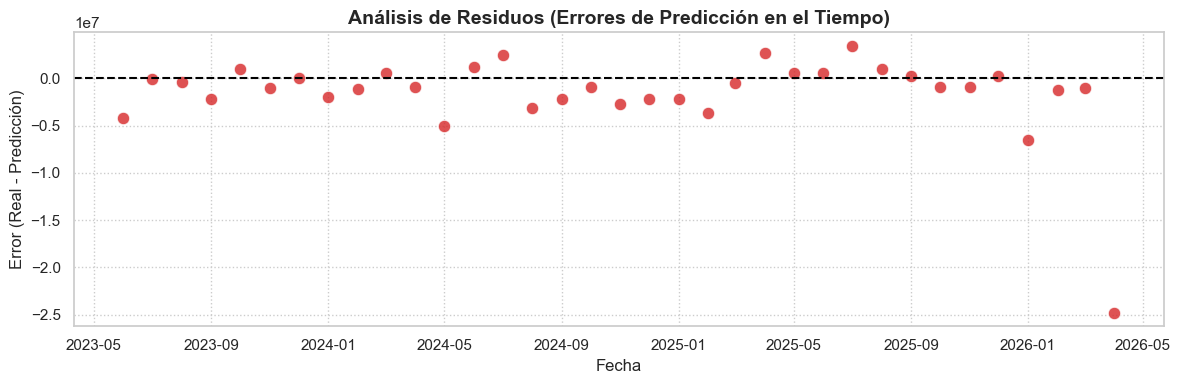

In [39]:
# 1. Creamos un DataFrame temporal para los gráficos de evaluación
df_resultados = pd.DataFrame({
    'Fecha': df_dataset_final_p2.loc[X_test.index, 'Fecha'],
    'Real': y_test,
    'Prediccion': y_pred
}).sort_values('Fecha')

# 2. Calculamos los residuos (error de cada mes)
df_resultados['Residuos'] = df_resultados['Real'] - df_resultados['Prediccion']

# ==========================================
# GRÁFICO 1: Predicción vs Valores Reales (Serie Temporal)
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(df_resultados['Fecha'], df_resultados['Real'], label='Consumo Real', color='tab:blue', marker='o', linewidth=2)
plt.plot(df_resultados['Fecha'], df_resultados['Prediccion'], label='Predicción Modelo Múltiple', color='tab:orange', linestyle='--', marker='s', linewidth=2)
plt.title('Validación del Modelo: Consumo Real vs Predicción (Set de Testeo)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Consumo Eléctrico', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO 2: Análisis de Residuos
# ==========================================
plt.figure(figsize=(12, 4))
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
sns.scatterplot(data=df_resultados, x='Fecha', y='Residuos', color='tab:red', s=80, alpha=0.8)
plt.title('Análisis de Residuos (Errores de Predicción en el Tiempo)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Error (Real - Predicción)', fontsize=12)
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

El modelo de Regresión Lineal Múltiple alcanzó un R2 de 0.4384 en el set de validación (testeo cronológico). Al observar el gráfico de Consumo Real vs. Predicción, se evidencia que el modelo captura correctamente la estacionalidad de la serie (los ciclos de aumento y descenso del consumo). Sin embargo, tiende a subestimar los picos de máxima demanda invernal.El Análisis de Residuos muestra una dispersión aleatoria en torno a la línea de cero, lo que valida que el modelo no presenta sesgos sistemáticos. La variabilidad no explicada (56.16%) sugiere la necesidad de incorporar en futuros trabajos variables climáticas directas (como temperaturas mínimas o días de helada) 